# 03. Model Evaluation, Threshold Optimization & Interpretability

**Project**: Customer Churn Prediction System
**Objective**: Evaluate the production model pipeline, analyze classification trade-offs, optimize the decision threshold for high churn recall, and inspect feature importance drivers.

In [1]:
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score

import sys
sys.path.append("..")
from src.features import build_features
from src.predict import load_model, predict_one

## 1. Load Model Pipeline & Metadata

In [2]:
model, feature_cols, metadata = load_model()
print("Model Name:", metadata.get("model_name"))
print("Optimal Threshold:", metadata.get("optimal_threshold"))
print("Test Metrics:", metadata.get("test_metrics"))

Model Name: Gradient Boosting
Optimal Threshold: 0.3594
Test Metrics: {'accuracy': 0.7799858055358411, 'precision': 0.5711111111111111, 'recall': 0.6871657754010695, 'f1': 0.6237864077669902, 'roc_auc': 0.8441060218553824, 'pr_auc': 0.659912115620412, 'threshold': 0.3593818020948176}


## 2. Inspect Top Feature Importance Drivers

C:\Users\Asus\AppData\Local\Temp\ipykernel_18288\903726957.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weight", y="feature", data=top_feats, palette="viridis")


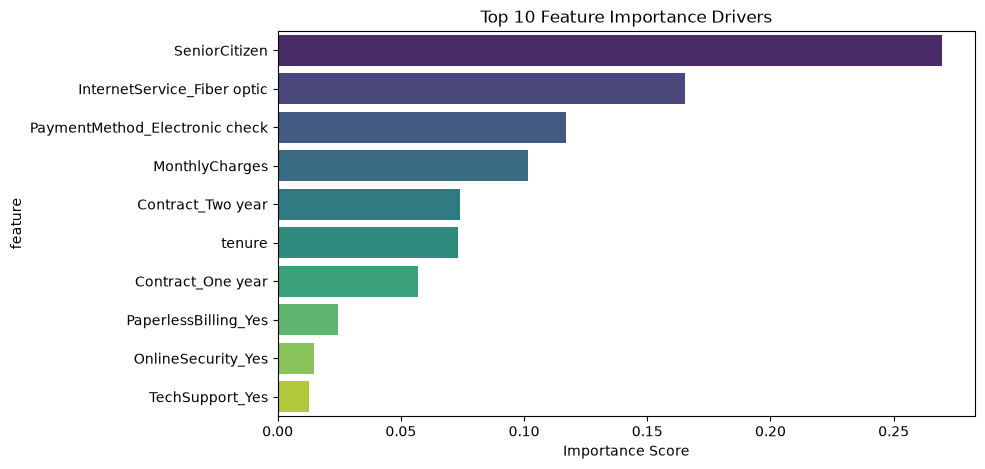

In [3]:
top_feats = pd.DataFrame(metadata.get("top_features", []))
plt.figure(figsize=(9, 5))
sns.barplot(x="weight", y="feature", data=top_feats, palette="viridis")
plt.title("Top 10 Feature Importance Drivers")
plt.xlabel("Importance Score")
plt.show()

## 3. Real-Time Single Customer Prediction Test

In [4]:
test_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 3,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 88.50,
    "TotalCharges": 265.50
}

pred = predict_one(test_customer)
print("Prediction Result:")
print(json.dumps(pred, indent=2))

Prediction Result:
{
  "prediction": "Likely to churn",
  "churn_probability": 0.7383,
  "churn_percentage": 73.8,
  "risk_level": "High",
  "threshold": 0.3594,
  "model_name": "Gradient Boosting",
  "model_version": "1.0.0",
  "risk_factors": [
    {
      "type": "risk",
      "feature": "Contract",
      "impact": "High Risk (+)",
      "description": "Month-to-month contracts have historically highest churn rates (~42%)."
    },
    {
      "type": "risk",
      "feature": "Tenure",
      "impact": "High Risk (+)",
      "description": "Tenure of only 3 months; new customers are most vulnerable to churn."
    },
    {
      "type": "risk",
      "feature": "Internet Service",
      "impact": "Moderate Risk (+)",
      "description": "Fiber optic accounts exhibit higher churn due to competitive pricing alternatives."
    },
    {
      "type": "risk",
      "feature": "Monthly Charges",
      "impact": "Moderate Risk (+)",
      "description": "Premium monthly spend ($88.50/mo) inc